Importing the Dependencies

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
import xgboost as xgb

Data Collection and Analysis

In [ ]:
#loading the diabetes dataset to a pandas Dataframe
diabetes_dataset = pd.read_csv('/content/diabetes_prediction_dataset.csv')

In [ ]:
#printing the dataset
diabetes_dataset.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [ ]:
#number of rows and columns in this dataset
print(diabetes_dataset.shape)

(100000, 9)


In [ ]:
#getting the statistical measures of the data
print(diabetes_dataset.describe())

                 age  hypertension  heart_disease            bmi  \
count  100000.000000  100000.00000  100000.000000  100000.000000   
mean       41.885856       0.07485       0.039420      27.320767   
std        22.516840       0.26315       0.194593       6.636783   
min         0.080000       0.00000       0.000000      10.010000   
25%        24.000000       0.00000       0.000000      23.630000   
50%        43.000000       0.00000       0.000000      27.320000   
75%        60.000000       0.00000       0.000000      29.580000   
max        80.000000       1.00000       1.000000      95.690000   

         HbA1c_level  blood_glucose_level       diabetes  
count  100000.000000        100000.000000  100000.000000  
mean        5.527507           138.058060       0.085000  
std         1.070672            40.708136       0.278883  
min         3.500000            80.000000       0.000000  
25%         4.800000           100.000000       0.000000  
50%         5.800000           14

In [ ]:
print(diabetes_dataset['diabetes'].value_counts())

diabetes
0    91500
1     8500
Name: count, dtype: int64


0---> Non-Diabetic

1---> Diabetic

In [ ]:
print(diabetes_dataset.groupby('diabetes').mean(numeric_only=True))

                age  hypertension  heart_disease        bmi  HbA1c_level  \
diabetes                                                                   
0         40.115187      0.058984       0.029235  26.887163     5.396761   
1         60.946588      0.245647       0.149059  31.988382     6.934953   

          blood_glucose_level  
diabetes                       
0                  132.852470  
1                  194.094706  


Split Features and Target Variable

In [ ]:
#separating the data and labels
X = diabetes_dataset.drop('diabetes', axis=1)
y = diabetes_dataset['diabetes']

Data Visualization

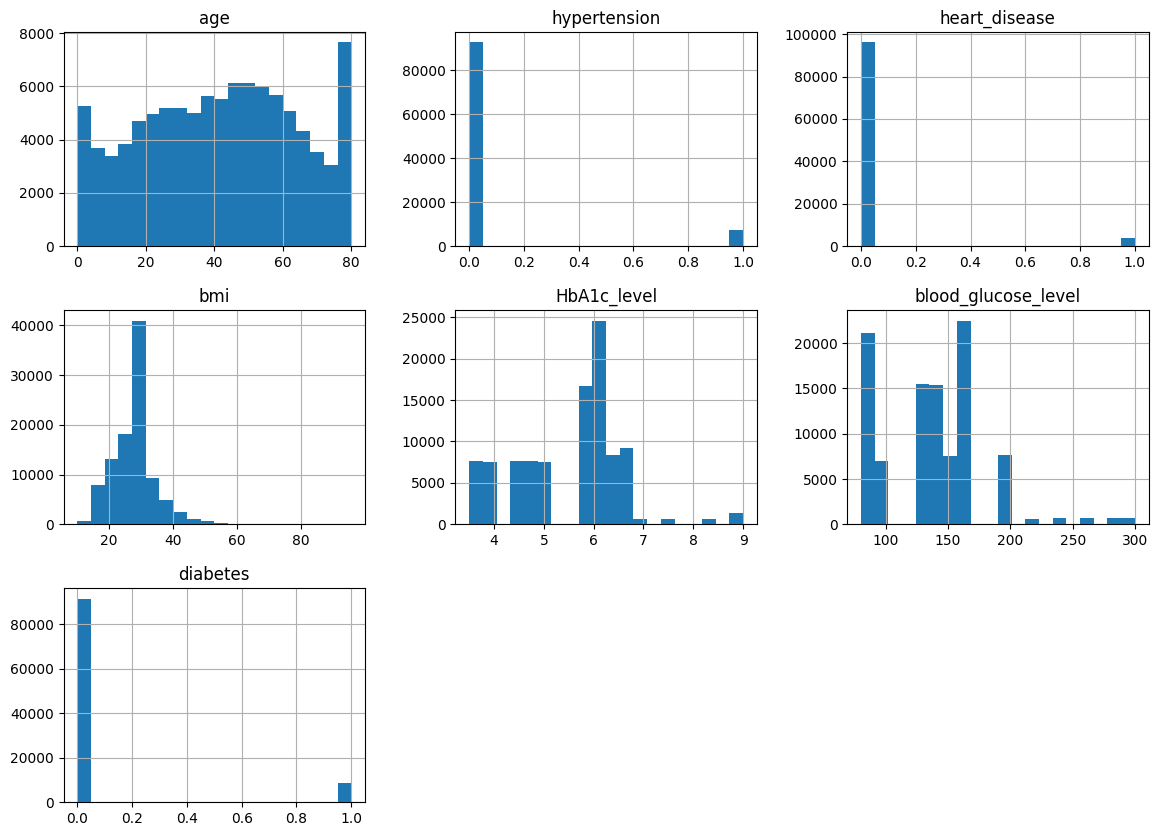

In [ ]:
#Feature distributions split
diabetes_dataset.hist(bins=20, figsize=(14,10))
plt.show()

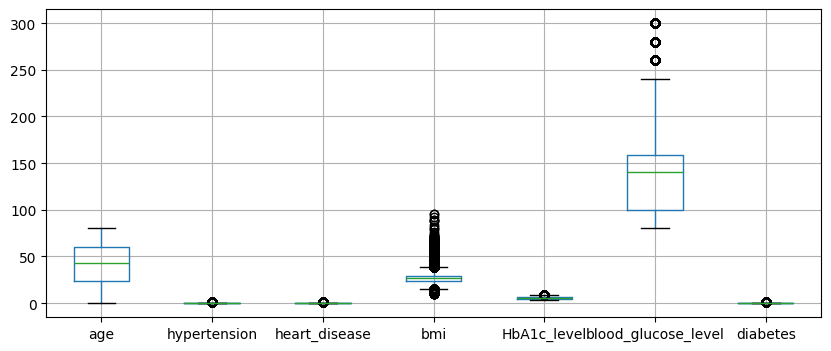

In [ ]:
#Using Box Plot to spot Outliers
diabetes_dataset.boxplot(figsize=(10,4))
plt.show()

In [ ]:
def cap_outliers(df, column_name):
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column_name] = df[column_name].clip(lower_bound, upper_bound)
    return df

for column_name in ['bmi', 'HbA1c_level', 'blood_glucose_level']:
        diabetes_dataset = cap_outliers(diabetes_dataset, column_name)

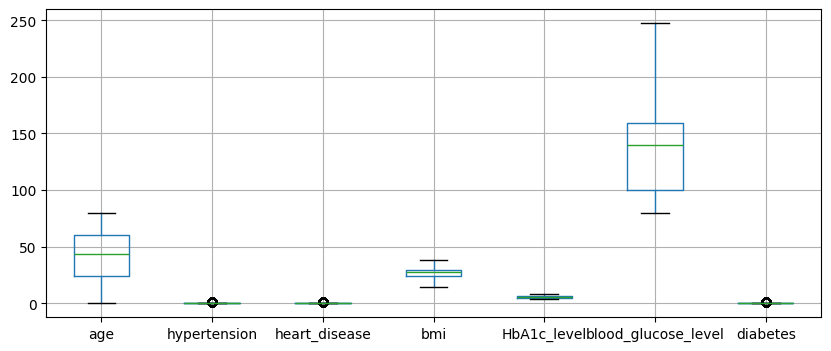

In [ ]:
diabetes_dataset.boxplot(figsize=(10,4))
plt.show()

Categorical vs Numeric

In [ ]:
#Define Column Types for Preprocessing
numeric_cols = ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']
categorical_cols = ['gender', 'smoking_history']

In [ ]:
#Creating Preprocessing Pipelines
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [ ]:
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_cols), ('cat', categorical_transformer, categorical_cols)])

Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2)

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print(X_train_processed.shape, X_test_processed.shape)

(80000, 15) (20000, 15)


K-Nearest Neighbors

In [ ]:
X_train_small = X_train_processed[:5000]
y_train_small = y_train[:5000]
X_test_small = X_test_processed[:1000]
y_test_small = y_test[:1000]
train_score = []
test_score = []
for i in range(1, 15):
    knn = KNeighborsClassifier(i, n_jobs=-1)
    knn.fit(X_train_small, y_train_small)
    train_score.append(knn.score(X_train_small, y_train_small))
    test_score.append(knn.score(X_test_small, y_test_small))

In [ ]:
print(train_score)
print(test_score)

[1.0, 0.969, 0.9712, 0.9646, 0.968, 0.961, 0.9644, 0.961, 0.9618, 0.9592, 0.9612, 0.958, 0.9586, 0.9584]
[0.946, 0.951, 0.952, 0.955, 0.952, 0.95, 0.954, 0.95, 0.958, 0.952, 0.956, 0.953, 0.955, 0.956]


In [ ]:
max_train_score = max(train_score)
train_score_ind = [i for i, v in enumerate(train_score) if v == max_train_score]
print('Max train score {} % and k = {}'.format(max_train_score * 100, list(map(lambda x: x + 1, train_score_ind))))

Max train score 100.0 % and k = [1]


In [ ]:
max_test_score = max(test_score)
test_score_ind = [i for i, v in enumerate(test_score) if v == max_test_score]
print('Max test score {} % and k = {}'.format(max_test_score * 100, list(map(lambda x: x + 1, test_score_ind))))

Max test score 95.8 % and k = [9]


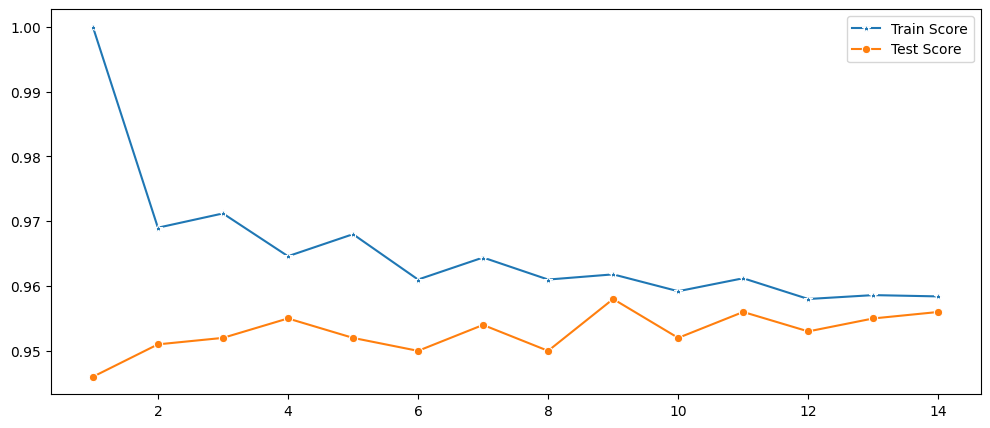

In [ ]:
#Plot Training vs test accuracy for different K values
plt.figure(figsize=(12,5))
sns.lineplot(x=range(1,15), y=train_score, marker='*', label='Train Score')
sns.lineplot(x=range(1,15), y=test_score, marker='o', label='Test Score')
plt.show()

Training KNN

In [ ]:
best_k = test_score.index(max(test_score)) + 1
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_processed, y_train)
print(knn.score(X_test_processed, y_test))

0.96305


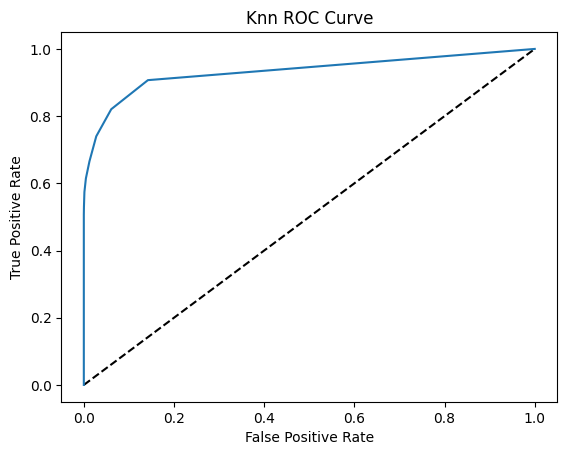

In [ ]:
#Plotting ROC Curve for KNN
y_pred_proba = knn.predict_proba(X_test_processed)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr, label='Knn')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Knn ROC Curve')
plt.show()

In [ ]:
print(roc_auc_score(y_test, y_pred_proba))

0.9325018964963034


Support Vector Machine(SVM)

In [ ]:
classifier = SVC(kernel='linear')
classifier.fit(X_train_processed, y_train)

SVC(kernel='linear')

In [ ]:
X_train_prediction = classifier.predict(X_train_processed)
train_data_accuracy = accuracy_score(X_train_prediction, y_train)
print('Accuracy score of the training data:', train_data_accuracy)

Accuracy score of the training data: 0.960675


In [ ]:
X_test_prediction = classifier.predict(X_test_processed)
test_data_accuracy = accuracy_score(X_test_prediction, y_test)
print('Accuracy score of the test data:', test_data_accuracy)

Accuracy score of the test data: 0.96185


Making a Predictive System

In [ ]:
sample_row = pd.DataFrame([['Female', 44.0, 0, 0, 'never', 19.31, 6.5, 200]], columns=X.columns)
input_data = sample_row
std_data = preprocessor.transform(input_data)
prediction = classifier.predict(std_data)
print(prediction)
if prediction[0] == 0:
    print('The person is not diabetic')
else:
    print('The person is diabetic')

[0]
The person is not diabetic


Model Comparison

In [ ]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=50, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=50, random_state=42),
    'XGBoost'             : xgb.XGBClassifier(n_estimators=50, eval_metric='logloss', random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=best_k)

}

print(f"{'Model':<22} {'CV Accuracy':>12} {'Test Accuracy':>14} {'ROC-AUC':>10}")
print("─" * 62)

results = {}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_processed, y_train, cv=cv, scoring='accuracy')
    model.fit(X_train_processed, y_train)
    y_pred  = model.predict(X_test_processed)
    y_proba = model.predict_proba(X_test_processed)[:, 1]
    test_acc = accuracy_score(y_pred, y_test)
    auc      = roc_auc_score(y_test, y_proba)
    results[name] = {'model': model, 'y_pred': y_pred, 'roc_auc': auc, 'y_proba': y_proba}
    print(f"{name:<22} {cv_scores.mean():>11.3f}  {test_acc:>13.3f}  {auc:>9.3f}")

#Identifying best performing model

best_name = max(results, key=lambda x: results[x]['roc_auc'])
print(f"\nBest model : {best_name}")
print(classification_report(y_test, results[best_name]['y_pred'], target_names=['Healthy', 'Disease']))
print(confusion_matrix(y_test, results[best_name]['y_pred']))

Model                   CV Accuracy  Test Accuracy    ROC-AUC
──────────────────────────────────────────────────────────────
Logistic Regression          0.960          0.962      0.961
Random Forest                0.970          0.970      0.956
Gradient Boosting            0.972          0.973      0.978
XGBoost                      0.971          0.973      0.980
KNN                          0.960          0.963      0.933

Best model : XGBoost
              precision    recall  f1-score   support

     Healthy       0.97      1.00      0.99     18300
     Disease       0.97      0.70      0.81      1700

    accuracy                           0.97     20000
   macro avg       0.97      0.85      0.90     20000
weighted avg       0.97      0.97      0.97     20000

[[18264    36]
 [  507  1193]]
